# Notebook 2 - Data Exploration

## Why this notebook exists

Notebook 1 told us *what* the data looks like. Notebook 2 asks a harder
question:

> "Which customer behaviours are linked to churn, and what do those patterns
> mean for the business?"

We do **not** train a prediction model here. We explore, draw charts, run a
few simple statistical checks, and group similar customers with K-means.
The findings become the reasons behind every cleaning and modelling choice
in notebooks 3–8.

| | |
|---|---|
| **Input** | `data/clean/step1_customers.csv` (from notebook 1) |
| **Output** | charts in `figures/`, a few summary tables in `data/clean/` |
| **Why it is needed** | Without exploration we cannot defend *why* we engineered certain features, which columns matter, or which retention actions make sense. |

## Step 0 - Tools and file locations

We use four libraries only:

- `os` - create folders if needed
- `pandas` - tables
- `matplotlib` - charts
- `sklearn` - K-means clustering and one scaling helper

We deliberately do **not** use Plotly, SHAP, or automatic profiling tools here.
A simple bar chart you can explain is better for a viva than a heavy HTML report.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

CLEAN_FOLDER = "../data/clean"
FIGURE_FOLDER = "../figures"

os.makedirs(CLEAN_FOLDER, exist_ok=True)
os.makedirs(FIGURE_FOLDER, exist_ok=True)

customers = pd.read_csv(CLEAN_FOLDER + "/step1_customers.csv")

print("Loaded customers:", customers.shape[0])
print("Columns:", customers.shape[1])
customers.head()

Loaded customers: 5630
Columns: 20


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Step 1 - Fix messy category labels (for analysis only)

Some text columns use two names for the same thing:

- `Phone` and `Mobile Phone`
- `CC` and `Credit Card`
- `COD` and `Cash on Delivery`
- `Mobile` and `Mobile Phone` (order category)

If we leave them separate, charts and models will treat them as different
groups. We make a working copy called `eda` and fix the labels there.
The original CSV from notebook 1 stays unchanged; notebook 3 will apply the
final cleaning for modelling.

In [2]:
eda = customers.copy()

eda["PreferredLoginDevice"] = eda["PreferredLoginDevice"].replace(
    {"Phone": "Mobile Phone"}
)
eda["PreferredPaymentMode"] = eda["PreferredPaymentMode"].replace(
    {"CC": "Credit Card", "COD": "Cash on Delivery"}
)
eda["PreferedOrderCat"] = eda["PreferedOrderCat"].replace(
    {"Mobile": "Mobile Phone"}
)

print("Login devices:")
print(eda["PreferredLoginDevice"].value_counts())
print()
print("Payment modes:")
print(eda["PreferredPaymentMode"].value_counts())
print()
print("Order categories:")
print(eda["PreferedOrderCat"].value_counts())

Login devices:
PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64

Payment modes:
PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

Order categories:
PreferedOrderCat
Mobile Phone          2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64


## Step 2 - Outliers in number columns

An **outlier** is a value that is unusually far from the middle of the data.
We use the common IQR rule:

1. Find Q1 (25th percentile) and Q3 (75th percentile).
2. IQR = Q3 − Q1.
3. Anything below Q1 − 1.5×IQR or above Q3 + 1.5×IQR is counted as an outlier.

We do **not** delete outliers. Extreme delivery distances or cashback amounts
can be real customers. Later we will use a robust scaler so those extremes
do not dominate the model.

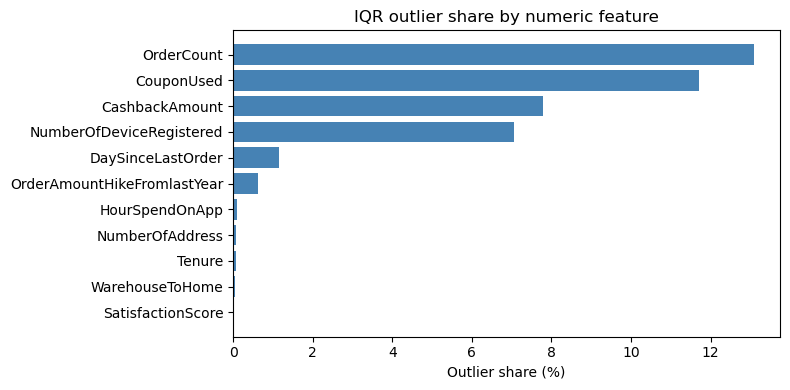

,feature,outlier_percent
4,SatisfactionScore,0.00
1,WarehouseToHome,0.04
0,Tenure,0.07
5,NumberOfAddress,0.07
2,HourSpendOnApp,0.11
6,OrderAmountHikeFromlastYear,0.62
9,DaySinceLastOrder,1.16
3,NumberOfDeviceRegistered,7.05
10,CashbackAmount,7.78
7,CouponUsed,11.70


In [3]:
numeric_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "NumberOfAddress",
    "OrderAmountHikeFromlastYear",
    "CouponUsed",
    "OrderCount",
    "DaySinceLastOrder",
    "CashbackAmount",
]

outlier_rows = []

for column_name in numeric_columns:
    values = eda[column_name].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    number_outliers = ((values < low) | (values > high)).sum()
    percent_outliers = number_outliers / len(values) * 100

    outlier_rows.append([column_name, round(percent_outliers, 2)])

outlier_table = pd.DataFrame(outlier_rows, columns=["feature", "outlier_percent"])
outlier_table = outlier_table.sort_values("outlier_percent")
outlier_table.to_csv(CLEAN_FOLDER + "/step2_outlier_summary.csv", index=False)

plt.figure(figsize=(8, 4))
plt.barh(outlier_table["feature"], outlier_table["outlier_percent"], color="steelblue")
plt.xlabel("Outlier share (%)")
plt.title("IQR outlier share by numeric feature")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/2_outlier_share.png", dpi=150)
plt.show()

outlier_table

### What this chart tells us

Taller bars mean more extreme values. Features like order count, coupons, or
cashback often have long right tails in retail data. That is normal.

**Decision for later notebooks:** keep the outliers, but scale with a method
that is less sensitive to extremes (RobustScaler in notebook 3).

## Step 3 - Look at category and number distributions

Before comparing groups, we look at each column alone. This is called
**univariate** analysis: one variable at a time.

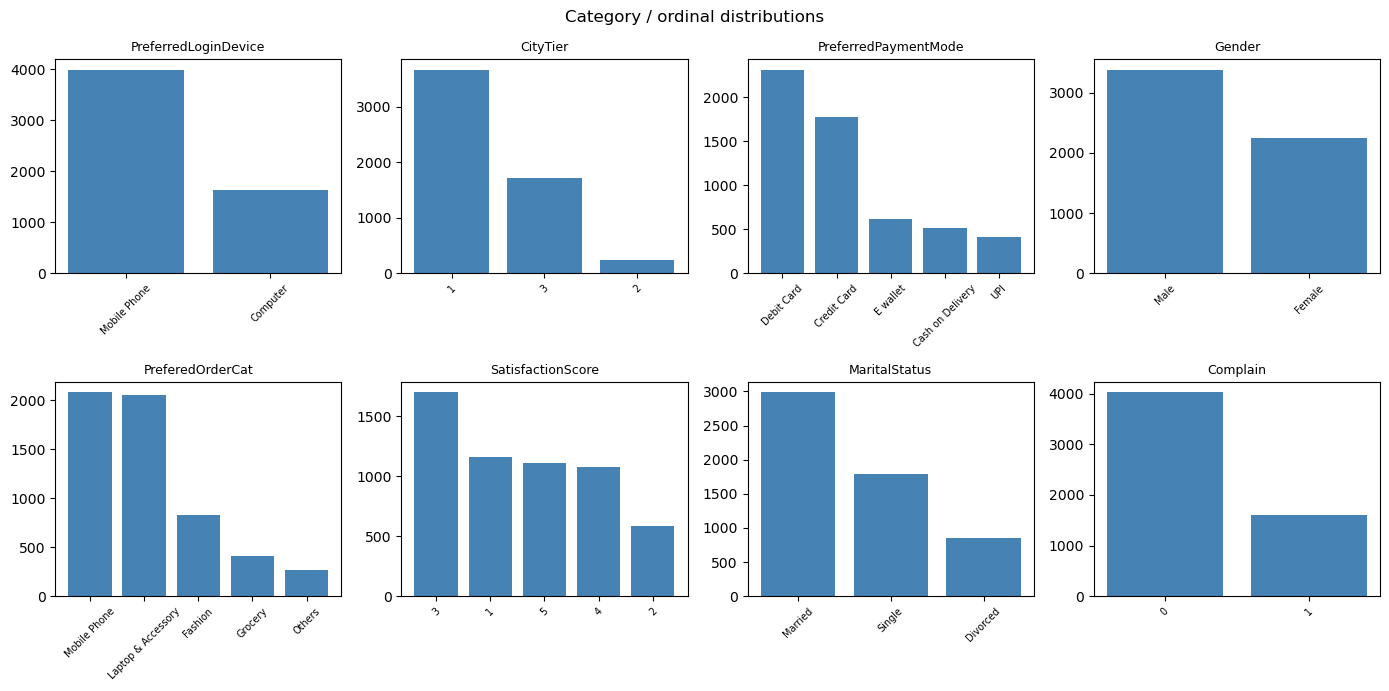

In [4]:
category_columns = [
    "PreferredLoginDevice",
    "CityTier",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "SatisfactionScore",
    "MaritalStatus",
    "Complain",
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for i in range(len(category_columns)):
    column_name = category_columns[i]
    counts = eda[column_name].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color="steelblue")
    axes[i].set_title(column_name, fontsize=9)
    axes[i].tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Category / ordinal distributions")
fig.tight_layout()
fig.savefig(FIGURE_FOLDER + "/2_category_distributions.png", dpi=150)
plt.show()

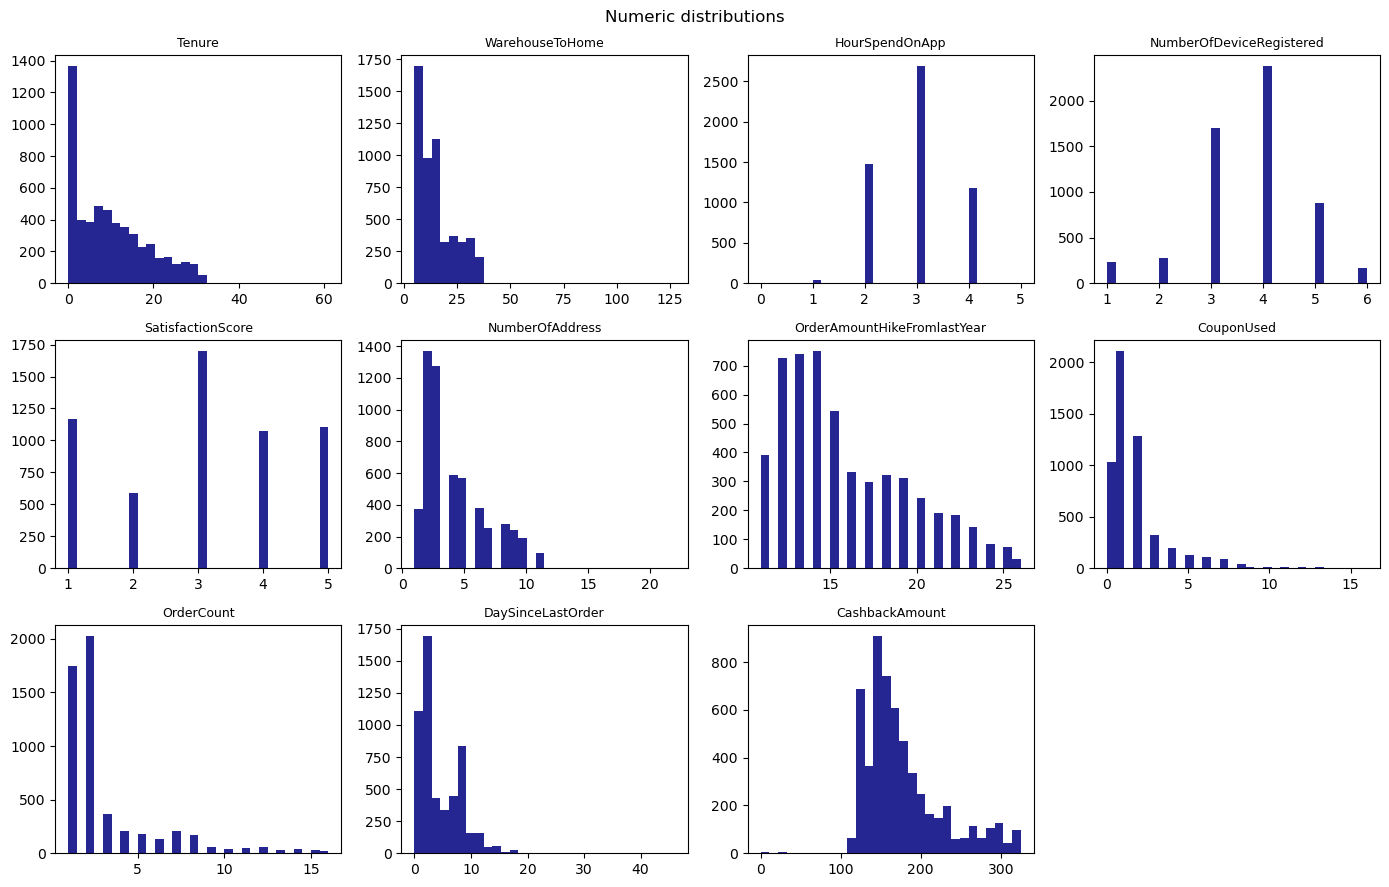

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.ravel()

for i in range(len(numeric_columns)):
    column_name = numeric_columns[i]
    axes[i].hist(eda[column_name].dropna(), bins=30, color="navy", alpha=0.85)
    axes[i].set_title(column_name, fontsize=9)

# Turn off unused subplot boxes
for j in range(len(numeric_columns), len(axes)):
    axes[j].axis("off")

fig.suptitle("Numeric distributions")
fig.tight_layout()
fig.savefig(FIGURE_FOLDER + "/2_numeric_distributions.png", dpi=150)
plt.show()

### What these charts tell us

- Debit/Credit cards are common payment modes; Married is the largest marital
  group; Laptop & Accessory and Mobile Phone dominate order categories.
- Tenure, OrderCount, CouponUsed and DaySinceLastOrder are **right-skewed**
  (most customers cluster at lower values, with a long tail to the right).
  That is why we prefer median imputation and robust scaling later.

## Step 3b - Correlation heatmap (numeric features)

A **correlation heatmap** shows how numeric columns move together.

- Values near **+1** mean two features rise together
- Values near **-1** mean one rises when the other falls
- Values near **0** mean little linear relationship

We include `Churn` so we can see which numbers relate most to leaving.
Strong pairs among predictors also hint at redundancy (useful context for
GA/PSO feature selection later — we do **not** need PCA here).


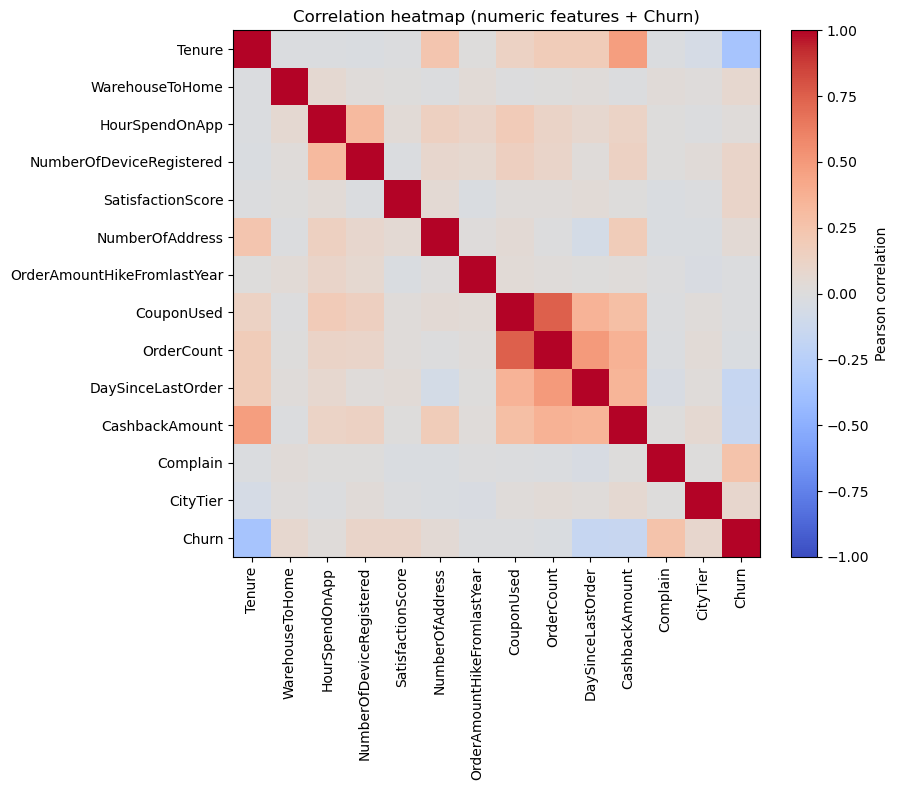

Strongest |correlation| with Churn:
Tenure                      0.349
Complain                    0.250
DaySinceLastOrder           0.161
CashbackAmount              0.154
NumberOfDeviceRegistered    0.108
SatisfactionScore           0.105
CityTier                    0.085
WarehouseToHome             0.077
Name: Churn, dtype: float64
Saved: ../data/clean/step2_correlation_matrix.csv


In [5]:
# Include Complain / CityTier too (strong business signals)
corr_cols = numeric_columns + ["Complain", "CityTier", "Churn"]
corr_cols = list(dict.fromkeys(corr_cols))  # keep order, drop duplicates
corr_matrix = eda[corr_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation heatmap (numeric features + Churn)")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/2_correlation_heatmap.png", dpi=150)
plt.show()

churn_corr = corr_matrix["Churn"].drop("Churn").abs().sort_values(ascending=False)
print("Strongest |correlation| with Churn:")
print(churn_corr.head(8).round(3))
corr_matrix.round(3).to_csv(CLEAN_FOLDER + "/step2_correlation_matrix.csv")
print("Saved:", CLEAN_FOLDER + "/step2_correlation_matrix.csv")


## Step 4 - Churn rate by every important category

This is **bivariate** analysis: we compare each feature against `Churn`.
For each group we compute:

> churn rate = (number who left) / (number in that group)

Groups with a much higher churn rate are strong risk signals.


=== Churn rate by Complain ===
 Complain  churn_rate    n
        1    0.316708 1604
        0    0.109290 4026


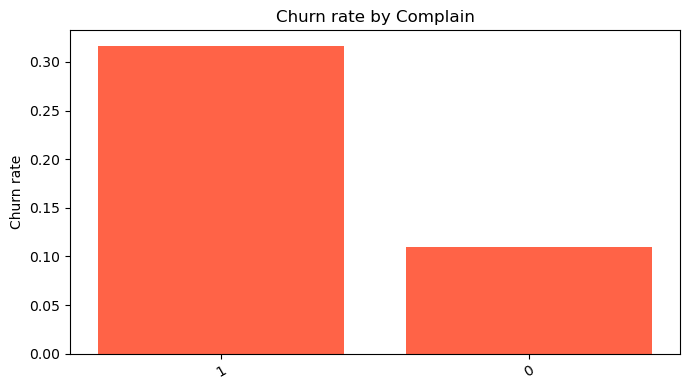


=== Churn rate by SatisfactionScore ===
 SatisfactionScore  churn_rate    n
                 5    0.238267 1108
                 3    0.171967 1698
                 4    0.171322 1074
                 2    0.126280  586
                 1    0.115120 1164


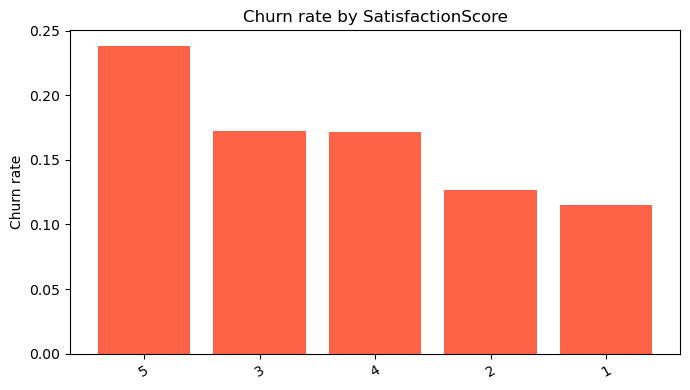


=== Churn rate by MaritalStatus ===
MaritalStatus  churn_rate    n
       Single    0.267261 1796
     Divorced    0.146226  848
      Married    0.115204 2986


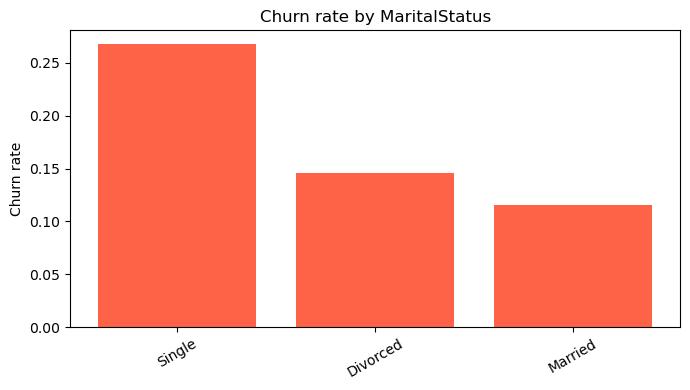


=== Churn rate by PreferedOrderCat ===
  PreferedOrderCat  churn_rate    n
      Mobile Phone    0.274038 2080
           Fashion    0.154964  826
Laptop & Accessory    0.102439 2050
            Others    0.075758  264
           Grocery    0.048780  410


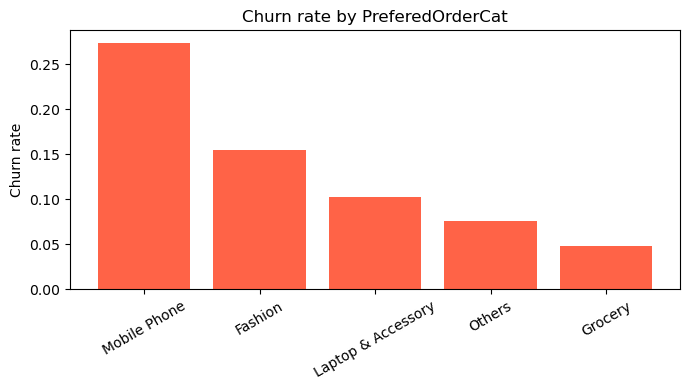

In [ ]:
def churn_rate_table(column_name):
    """Return a small table: each group, its churn rate, and its size."""
    rows = []
    groups = eda[column_name].dropna().unique()

    for group_value in groups:
        group_rows = eda[eda[column_name] == group_value]
        rate = group_rows["Churn"].mean()
        size = len(group_rows)
        rows.append([group_value, rate, size])

    table = pd.DataFrame(rows, columns=[column_name, "churn_rate", "n"])
    table = table.sort_values("churn_rate", ascending=False)
    return table


# Focus on the clearest business signals for the viva
focus_columns = ["Complain", "SatisfactionScore", "MaritalStatus", "PreferedOrderCat"]

for column_name in focus_columns:
    table = churn_rate_table(column_name)
    print()
    print("=== Churn rate by", column_name, "===")
    print(table.to_string(index=False))

    plt.figure(figsize=(7, 4))
    plt.bar(table[column_name].astype(str), table["churn_rate"], color="tomato")
    plt.ylabel("Churn rate")
    plt.title("Churn rate by " + column_name)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(FIGURE_FOLDER + "/2_churn_by_" + column_name + ".png", dpi=150)
    plt.show()

### Business reading

- **Complain = 1** customers leave far more often. Complaint recovery is the
  most actionable lever in this dataset.
- **Low SatisfactionScore** also links to higher churn. Combining low
  satisfaction with a complaint creates a high-risk segment (we will create
  that flag in notebook 3).
- Marital status and order category show smaller but still useful differences.

## Step 5 - Number columns: do churned customers look different?

A **boxplot** shows the middle of a number column and how spread out it is.
We draw one box for customers who stayed and one for customers who left.
If the boxes sit in different places, that number is useful for prediction.

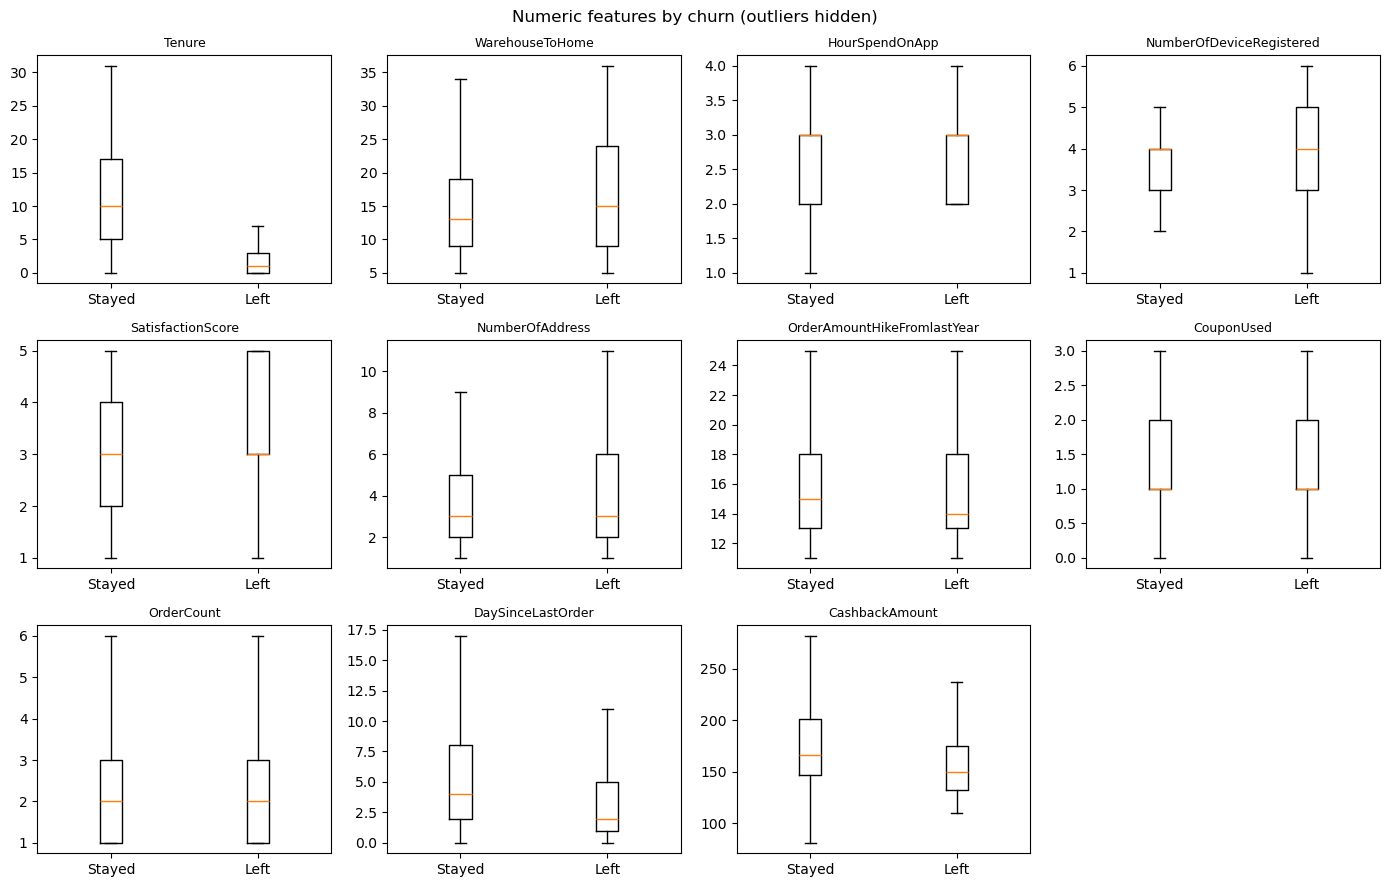

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.ravel()

for i in range(len(numeric_columns)):
    column_name = numeric_columns[i]
    stayed = eda.loc[eda["Churn"] == 0, column_name].dropna()
    left = eda.loc[eda["Churn"] == 1, column_name].dropna()
    axes[i].boxplot([stayed, left], tick_labels=["Stayed", "Left"], showfliers=False)
    axes[i].set_title(column_name, fontsize=9)

for j in range(len(numeric_columns), len(axes)):
    axes[j].axis("off")

fig.suptitle("Numeric features by churn (outliers hidden)")
fig.tight_layout()
fig.savefig(FIGURE_FOLDER + "/2_boxplots_by_churn.png", dpi=150)
plt.show()

### What this chart tells us

Churned customers often have **shorter tenure** (newer accounts). Recency
(`DaySinceLastOrder`) and reward/cashback profiles also differ. Tenure and
complaints should be first-class features in the model.

## Step 6 - Tenure cohorts (binning for insight)

**Binning** groups a continuous number into a few meaningful bands. Here we
cut tenure into New / Early / Mid / Long. This is a form of concept hierarchy:
raw months → life-stage group that a CRM team can act on.

TenureCohort  churn_rate    n
    New(0-3)    0.418590 1560
  Early(3-9)    0.066616 1321
   Mid(9-15)    0.061538 1105
   Long(15+)    0.042029 1380


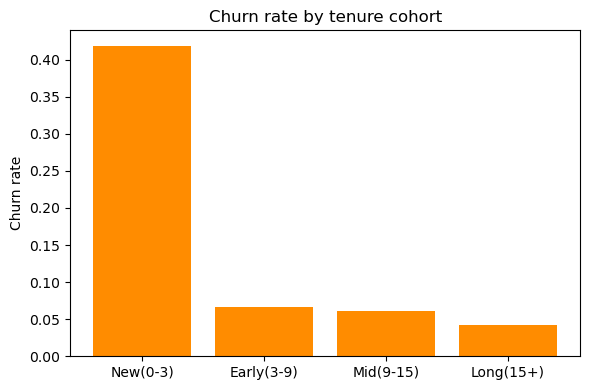

In [ ]:
eda["TenureCohort"] = pd.cut(
    eda["Tenure"],
    bins=[-0.1, 3, 9, 15, 100],
    labels=["New(0-3)", "Early(3-9)", "Mid(9-15)", "Long(15+)"],
)

cohort_table = churn_rate_table("TenureCohort")
print(cohort_table.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(cohort_table["TenureCohort"].astype(str), cohort_table["churn_rate"], color="darkorange")
plt.ylabel("Churn rate")
plt.title("Churn rate by tenure cohort")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/2_tenure_cohorts.png", dpi=150)
plt.show()

### What this chart tells us

**New customers (0–3 months)** are usually the riskiest band. Onboarding,
first delivery quality, and early support matter more than late loyalty
campaigns for this group. Notebook 3 will keep a `TenureBin` feature based on
this idea.

## Step 7 - Simple association checks

Charts suggest patterns. Two standard tests make those patterns more
defensible in a viva:

1. **Chi-square test** for a category vs churn: "Is the churn rate different
   across groups more than chance would allow?"
2. **Median comparison** for a number vs churn: "Is the typical value
   different for people who left?"

We also compute a simple strength score called **Cramer's V** (0 = no link,
closer to 1 = stronger link).

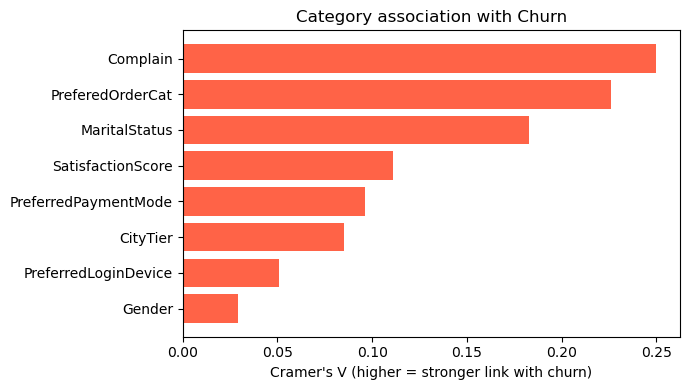

,feature,p_value,cramers_v
7,Complain,0.000000,0.250
4,PreferedOrderCat,0.000000,0.226
6,MaritalStatus,0.000000,0.183
5,SatisfactionScore,0.000000,0.111
2,PreferredPaymentMode,0.000000,0.096
1,CityTier,0.000000,0.085
0,PreferredLoginDevice,0.000148,0.051
3,Gender,0.030821,0.029


In [ ]:
from scipy import stats
import math

association_rows = []

for column_name in category_columns:
    # Contingency table: rows = category groups, columns = stayed / left
    contingency = pd.crosstab(eda[column_name], eda["Churn"])
    chi2, p_value, degrees_of_freedom, expected = stats.chi2_contingency(contingency)

    n = contingency.to_numpy().sum()
    n_rows = contingency.shape[0]
    n_cols = contingency.shape[1]
    cramers_v = math.sqrt(chi2 / (n * (min(n_rows, n_cols) - 1)))

    association_rows.append([column_name, round(p_value, 6), round(cramers_v, 3)])

association_table = pd.DataFrame(
    association_rows, columns=["feature", "p_value", "cramers_v"]
)
association_table = association_table.sort_values("cramers_v")
association_table.to_csv(CLEAN_FOLDER + "/step2_category_association.csv", index=False)

plt.figure(figsize=(7, 4))
plt.barh(association_table["feature"], association_table["cramers_v"], color="tomato")
plt.xlabel("Cramer's V (higher = stronger link with churn)")
plt.title("Category association with Churn")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/2_cramers_v.png", dpi=150)
plt.show()

association_table.sort_values("cramers_v", ascending=False)

In [ ]:
median_rows = []

for column_name in numeric_columns:
    stayed = eda.loc[eda["Churn"] == 0, column_name].dropna()
    left = eda.loc[eda["Churn"] == 1, column_name].dropna()
    median_rows.append(
        [
            column_name,
            round(stayed.median(), 2),
            round(left.median(), 2),
            round(left.median() - stayed.median(), 2),
        ]
    )

median_table = pd.DataFrame(
    median_rows,
    columns=["feature", "median_stayed", "median_left", "difference"],
)
median_table = median_table.sort_values("difference", key=abs, ascending=False)
median_table.to_csv(CLEAN_FOLDER + "/step2_numeric_medians.csv", index=False)
median_table

,feature,median_stayed,median_left,difference
10,CashbackAmount,166.12,149.66,-16.46
0,Tenure,10.00,1.00,-9.00
1,WarehouseToHome,13.00,15.00,2.00
9,DaySinceLastOrder,4.00,2.00,-2.00
6,OrderAmountHikeFromlastYear,15.00,14.00,-1.00
2,HourSpendOnApp,3.00,3.00,0.00
3,NumberOfDeviceRegistered,4.00,4.00,0.00
4,SatisfactionScore,3.00,3.00,0.00
5,NumberOfAddress,3.00,3.00,0.00
7,CouponUsed,1.00,1.00,0.00


### What these tables tell us

- Expect **Complain** near the top of Cramer's V — strongest category link.
- A tiny p-value (for example below 0.05) means the difference is unlikely to
  be pure chance.
- Median differences highlight numbers like **Tenure** where leavers look
  systematically different from stayers.

## Step 8 - Interaction: complaint × satisfaction

Sometimes two columns matter more **together** than alone. Customers who
complained *and* gave a low satisfaction score are a classic high-risk group.
We check the average churn rate for each combination.

 Complain  SatisfactionScore  churn_rate
        0                  1    0.070707
        0                  2    0.076923
        0                  3    0.104405
        0                  4    0.099256
        0                  5    0.183206
        1                  1    0.209677
        1                  2    0.247059
        1                  3    0.347458
        1                  4    0.388060
        1                  5    0.372671


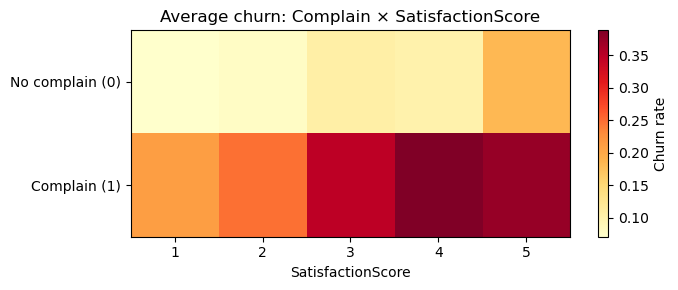

In [ ]:
interaction = (
    eda.groupby(["Complain", "SatisfactionScore"])["Churn"]
    .mean()
    .reset_index()
)
interaction = interaction.rename(columns={"Churn": "churn_rate"})
print(interaction.to_string(index=False))

# Simple heatmap-style plot using a pivot table
pivot = interaction.pivot(
    index="Complain", columns="SatisfactionScore", values="churn_rate"
)

plt.figure(figsize=(7, 3))
image = plt.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(image, label="Churn rate")
plt.yticks([0, 1], ["No complain (0)", "Complain (1)"])
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.xlabel("SatisfactionScore")
plt.title("Average churn: Complain × SatisfactionScore")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/2_complain_satisfaction.png", dpi=150)
plt.show()

### What this chart tells us

Darker cells mean higher churn. The combination **complaint + low satisfaction**
is especially dangerous. Notebook 3 will create a feature called
`UnhappyComplain` for exactly this pattern.

## Step 9 - Customer segmentation with K-means

Prediction answers: "Will *this* customer leave?"
Segmentation answers: "What *kinds* of customers do we have?"

**K-means** places customers into K groups so that people inside a group are
similar on the chosen behaviour columns. We:

1. Pick a few behaviour columns.
2. Drop rows with blanks in those columns (clustering needs complete numbers).
3. Scale the columns so distance is fair (Tenure in months vs Cashback in money).
4. Try several values of K and pick the one with the best **silhouette score**.
5. Look at each cluster's average churn rate.

Clustering is for CRM insight. The final predictor is still a supervised model.

Customers used for clustering: 4039


k = 2 | silhouette = 0.257


k = 3 | silhouette = 0.154


k = 4 | silhouette = 0.129


k = 5 | silhouette = 0.144


k = 6 | silhouette = 0.135


k = 7 | silhouette = 0.13


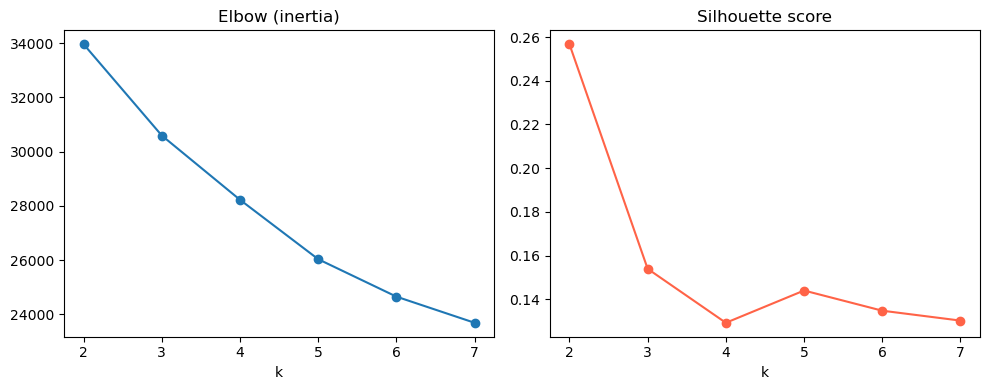

Selected k: 2


In [ ]:
RANDOM_SEED = 42

segment_columns = [
    "Tenure",
    "WarehouseToHome",
    "HourSpendOnApp",
    "NumberOfDeviceRegistered",
    "SatisfactionScore",
    "Complain",
    "OrderCount",
    "DaySinceLastOrder",
    "CouponUsed",
    "CashbackAmount",
]

segment = eda[segment_columns + ["Churn", "CustomerID"]].dropna().copy()
print("Customers used for clustering:", len(segment))

scaler = StandardScaler()
scaled_values = scaler.fit_transform(segment[segment_columns])

k_values = [2, 3, 4, 5, 6, 7]
inertias = []
silhouettes = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = model.fit_predict(scaled_values)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(scaled_values, labels))
    print("k =", k, "| silhouette =", round(silhouettes[-1], 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow (inertia)")
axes[0].set_xlabel("k")
axes[1].plot(k_values, silhouettes, marker="o", color="tomato")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k")
fig.tight_layout()
fig.savefig(FIGURE_FOLDER + "/2_kmeans_elbow_silhouette.png", dpi=150)
plt.show()

# Pick the k with the highest silhouette score
best_index = silhouettes.index(max(silhouettes))
best_k = k_values[best_index]
print("Selected k:", best_k)

            Tenure  WarehouseToHome  HourSpendOnApp  NumberOfDeviceRegistered  \
cluster                                                                         
0         8.611486        15.740786        2.966523                  3.747236   
1        13.426564        15.185185        3.080460                  3.849298   

         SatisfactionScore  Complain  OrderCount  DaySinceLastOrder  \
cluster                                                               
0                 3.042383  0.282555    1.951167           3.768120   
1                 3.121328  0.272031    7.446999           8.606641   

         CouponUsed  CashbackAmount     Churn     n  
cluster                                              
0          1.210995      164.872171  0.170147  3256  
1          4.286079      209.229119  0.116220   783  


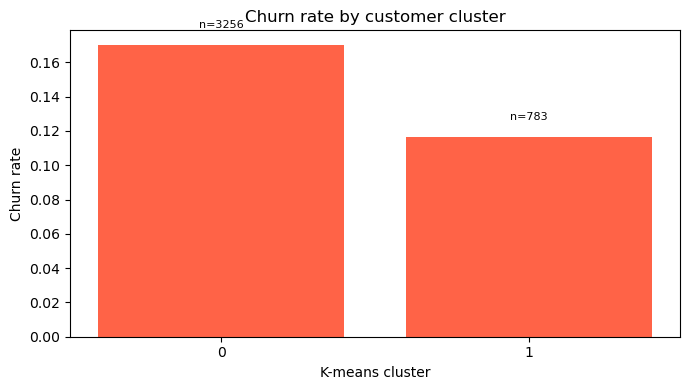

,cluster,churn_rate,n
0,0,0.170147,3256
1,1,0.116220,783


In [ ]:
final_model = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=10)
segment["cluster"] = final_model.fit_predict(scaled_values)

profile = segment.groupby("cluster")[segment_columns + ["Churn"]].mean()
profile["n"] = segment.groupby("cluster").size()
profile.to_csv(CLEAN_FOLDER + "/step2_kmeans_profiles.csv")
print(profile)

churn_by_cluster = segment.groupby("cluster")["Churn"].agg(["mean", "count"]).reset_index()
churn_by_cluster.columns = ["cluster", "churn_rate", "n"]

plt.figure(figsize=(7, 4))
bars = plt.bar(
    churn_by_cluster["cluster"].astype(str),
    churn_by_cluster["churn_rate"],
    color="tomato",
)
plt.xlabel("K-means cluster")
plt.ylabel("Churn rate")
plt.title("Churn rate by customer cluster")

for i in range(len(churn_by_cluster)):
    rate = churn_by_cluster.loc[i, "churn_rate"]
    size = churn_by_cluster.loc[i, "n"]
    plt.text(i, rate + 0.01, "n=" + str(int(size)), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/2_cluster_churn.png", dpi=150)
plt.show()

churn_by_cluster

### What clustering tells us

Clusters with the tallest churn bars are priority CRM segments. The profile
table shows *why* (for example short tenure + more complaints).

Remember:

- Clustering explains **groups**.
- Classification (later notebooks) predicts **individuals**.

We do not need hierarchical clustering as well — one clear segmentation method
is enough to explain in a viva.

## Conclusion of notebook 2 - modelling hypotheses

From exploration we carry these decisions into the rest of the project:

1. **Complain** and **low SatisfactionScore** jointly mark urgent risk → keep
   both and build an interaction flag.
2. **Short Tenure** cohorts churn more → keep tenure and a tenure bin.
3. Overlapping labels in device / payment / category inflate dimensions →
   harmonise them in preprocessing.
4. Skewed numbers + outliers → use median fill and RobustScaler; do not delete
   outliers that may be real customers.
5. Missing behaviour fields are scattered → median/mode imputation is enough.
6. Clusters give business segments; supervised models still own prediction.
   GA/PSO later may drop weak features if F1 stays high.

**Files created**

- `data/clean/step2_outlier_summary.csv`
- `data/clean/step2_correlation_matrix.csv`
- `figures/2_correlation_heatmap.png`
- `data/clean/step2_category_association.csv`
- `data/clean/step2_numeric_medians.csv`
- `data/clean/step2_kmeans_profiles.csv`
- Several charts in `figures/` starting with `2_`

**Next:** notebook 3 cleans, encodes, scales, and splits the data for modelling.